## Import libraries 

In [65]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

## Part 1 — Problem Definition & Dataset Verification

**Tasks**
## Problem Defination 
**The goal is to predict whether a customer will churn (Yes/No) based on their information.**

**1. Load clean_churn.csv (or re-run your Lab 2 cleaning) and verify its shape and dtypes**

In [66]:
df = pd.read_csv("clean_churn.csv")

In [67]:
df.shape

(7043, 31)

## Part 2 — Feature Scaling & Preparation

**3 Prepare X and y exactly as in Lab 3/4 (encode categoricals, drop identifiers,
                                           target as 0/1).**


In [68]:
X = df.drop(columns=["Churn"])

In [69]:
X

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No phone service,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,True,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,False,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,False,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,True,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,False,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,1,84.80,1990.50,False,...,True,False,True,False,True,True,False,False,False,True
7039,0,0,1,1,72,1,1,103.20,7362.90,False,...,False,False,True,False,True,True,False,True,False,False
7040,0,0,1,1,11,0,1,29.60,346.45,True,...,False,False,False,False,False,False,False,False,True,False
7041,1,1,1,0,4,1,1,74.40,306.60,False,...,False,False,False,False,False,False,False,False,False,True


In [70]:
##  Ensure boolean are converted to integre 0/1
X = X.astype(int)

In [71]:
X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No phone service,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29,29,1,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56,1889,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53,108,0,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42,1840,1,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,1,70,151,0,...,0,0,0,0,0,0,0,0,1,0


In [72]:
y = df["Churn"]

In [73]:

y.head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

**Task 4 In 2–3 sentences, explain why feature scaling matters for KNN and Logistic Regression but wasn't necessary for
the Decision Tree or Random Forest.**

## Ans 

**1. KNN & Logistic Regression**

**Features with larger values can dominate smaller-valued features.
So, we use feature scaling to put all features on a similar range.**

**2. Decision Tree & Random Forest**

**They make decisions using thresholds, like Age ≥ 30, rather than distances.
So, scaling is not necessary because changing the feature scale does not affect the split.**

## Task 5
**a )Split into train/test (same split strategy as Lab 3/4), then fit a StandardScaler on the training features only and
apply it to both sets.**



In [74]:
from sklearn.model_selection import train_test_split

In [102]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [103]:
## Applying the standard scaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [121]:
X_train_scaled = scaler.fit_transform(X_train)  # fit + transform
X_test_scaled = scaler.transform(X_test) 

array([[-1.02516569, -0.4377492 , -0.96957859, ..., -0.52765585,
        -0.70964983,  1.84247002],
       [-1.02516569, -0.4377492 , -0.96957859, ..., -0.52765585,
        -0.70964983, -0.54274967],
       [ 0.97545208, -0.4377492 ,  1.03137591, ..., -0.52765585,
         1.40914569, -0.54274967],
       ...,
       [ 0.97545208, -0.4377492 ,  1.03137591, ..., -0.52765585,
         1.40914569, -0.54274967],
       [ 0.97545208,  2.28441306, -0.96957859, ..., -0.52765585,
         1.40914569, -0.54274967],
       [ 0.97545208, -0.4377492 , -0.96957859, ...,  1.89517467,
        -0.70964983, -0.54274967]], shape=(5634, 30))

**b)Why is it important to fit the scaler only on the training data?**

**It is important to fit the scaler only on training data to prevent data leakage.**
**If we fit it on test data too, the model indirectly gets information about the test set, 
making the evaluation unfair and overly optimistic.**

## Part 3 — Logistic Regression

**Task 6 Train a LogisticRegression model on the scaled training data.
    Generate predictions on the scaled test set** 

In [105]:
from sklearn.linear_model import LogisticRegression

In [106]:
lr = LogisticRegression()

In [107]:
lr.fit(X_train_scaled,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [125]:
y_pred_lr = lr.predict(X_test_scaled)
y_pred_lr

array([1, 0, 0, ..., 0, 0, 0], shape=(1409,))

**Task 7**
**a) Compute accuracy, precision, recall, and F1-score**  

In [126]:
from sklearn.metrics import precision_score,accuracy_score,recall_score,f1_score
import matplotlib.pyplot as plt 
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [127]:
precision = precision_score(y_test,y_pred_lr)
accuracy= accuracy_score(y_test,y_pred_lr)
recall = recall_score(y_test,y_pred_lr)
f1  = f1_score(y_test,y_pred_lr)

metrics_table = pd.DataFrame({
    "Metrics" : ["Accracy","Precision","Recall","F1-Score"],
    "Score " : [accuracy,precision,recall,f1]
})

print(metrics_table.to_string(index=False))

  Metrics   Score 
  Accracy 0.819730
Precision 0.683077
   Recall 0.595174
 F1-Score 0.636103


**b plot the confusion matrix**

In [128]:
import matplotlib.pyplot as plt 
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


True Negatives : 915
False Positives: 121
False Negatives: 155
True Positives : 218

Actual churners: 373
Correctly caught churners: 218
Missed churners: 155


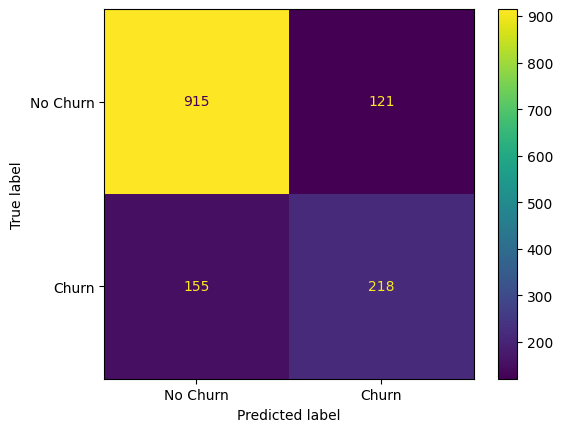

In [129]:
cm = confusion_matrix(y_test,y_pred)
tn, fp, fn, tp = cm.ravel()
print("\nTrue Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)
print("\nActual churners:", fn + tp)
print("Correctly caught churners:", tp)
print("Missed churners:", fn)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)
disp.plot()
plt.show()

**Task 8  Look at predict_proba for a handful of test customers. In 1–2 sentences, explain what these probabilities 
represent and how predict() turns them into a Yes/No decision**

**predict_proba for a handful of test customers**

In [130]:
probs = lr.predict_proba(X_test_scaled)

In [131]:
probabilty = pd.DataFrame(probs)

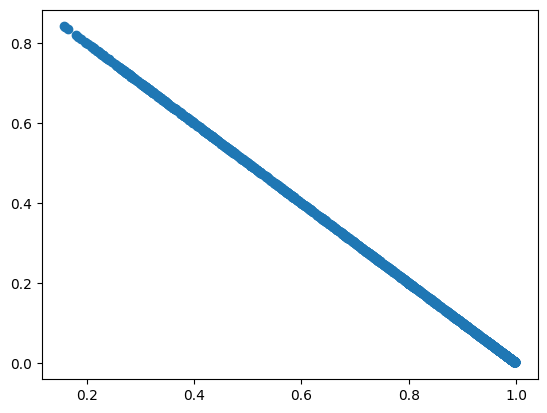

In [132]:
probabilty.to_string(index=False)
probabilty.sample(10)
plt.scatter(probabilty[0],probabilty[1])

## Part 4 — KNN & Choosing K

## Tasks

**9. Train KNN classifiers for several values of K (e.g. 1, 3, 5, 7, 9, 11, 15, 21) on the scaled data. Record test-set
accuracy and F1-score for each K in a results table**

In [133]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

k_values = [1, 3, 5, 7, 9, 11, 15, 21]

results = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)

    # Train the model
    knn.fit(X_train_scaled, y_train)

    # Make prediction
    y_pred = knn.predict(X_test_scaled)

    # Calculate the metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "K": k,
        "Accuracy": accuracy,
        "f1_score": f1
    })


results_df = pd.DataFrame(results)

print(results_df.to_string(index=False))

 K  Accuracy  f1_score
 1  0.735273  0.513690
 3  0.761533  0.542234
 5  0.775018  0.547789
 7  0.777147  0.551429
 9  0.792051  0.579627
11  0.795600  0.585014
15  0.796309  0.587050
21  0.804116  0.612360


**10 Plot accuracy (or F1) against K. Based on your plot**


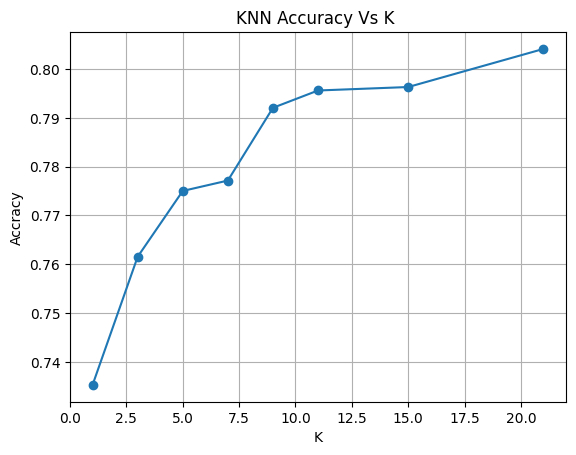

In [134]:

plt.plot(results_df["K"],results_df["Accuracy"],marker = "o")
plt.xlabel("K")
plt.ylabel("Accracy")
plt.title("KNN Accuracy Vs K ")
plt.grid(True)
plt.show()

**10 b)which K would you choose** 
## Ans : 
**which k for values of I tested, k = 21 has the highest accuarcy and f1_score so it 
is the value selected based on this comparision**

**why not simply the smallest
or largest value tested?**

**We should not simply choose the smallest or largest K because a very small K can be sensitive to noise, while a very large K can oversmooth the data. Therefore, K should be selected based on its performance.**

**Task 11. Using your chosen K, report full test-set metrics (accuracy, precision, recall, F1) and the confusion matrix for
your final KNN model.**

Accuracy : 0.8041163946061036
Precision: 0.6430678466076696
Recall   : 0.5844504021447721
F1-Score : 0.6123595505617978

Confusion Matrix:
[[915 121]
 [155 218]]


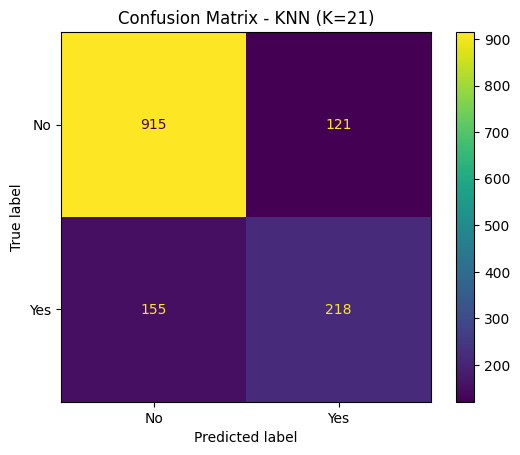

In [135]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
knn_final = KNeighborsClassifier(n_neighbors=21)
knn_final.fit(X_train_scaled,y_train)
y_pred_knn = knn_final.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred_knn)
precision = precision_score(y_test, y_pred_knn)
recall = recall_score(y_test, y_pred_knn)
f1 = f1_score(y_test, y_pred_knn)

cm = confusion_matrix(y_test,y_pred_knn)
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)

print("\nConfusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No", "Yes"]
)

disp.plot()
plt.title("Confusion Matrix - KNN (K=21)")
plt.show()


## Part 5 — Model Comparison (4 Models)

In [137]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# DecisionTree 

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train,y_train)
y_pred_dt = dt.predict(X_test)


# Random Forest 

rf = RandomForestClassifier(
      n_estimators=100,
      random_state=42
     )

rf.fit(X_train,y_train)

y_pred_rf = rf.predict(X_test)

print("Decision Tree")
print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1-score :", f1_score(y_test, y_pred_dt))

print("\nRandom Forest")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1-score :", f1_score(y_test, y_pred_rf))

Decision Tree
Accuracy : 0.7210787792760823
Precision: 0.47109826589595377
Recall   : 0.43699731903485256
F1-score : 0.4534075104311544

Random Forest
Accuracy : 0.794180269694819
Precision: 0.6602316602316602
Recall   : 0.4584450402144772
F1-score : 0.5411392405063291


**Task 12. Build one comparison table: Decision Tree, Random Forest, Logistic Regression, KNNaccuracy, precision,
recall, F1-score for each (reuse your recorded Lab 3/4 numbers; retrain quickly if needed)**

In [138]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = [
    {
        "Model": "Decision Tree",
        "Accuracy": accuracy_score(y_test, y_pred_dt),
        "Precision": precision_score(y_test, y_pred_dt),
        "Recall": recall_score(y_test, y_pred_dt),
        "F1-score": f1_score(y_test, y_pred_dt)
    },
    {
        "Model": "Random Forest",
        "Accuracy": accuracy_score(y_test, y_pred_rf),
        "Precision": precision_score(y_test, y_pred_rf),
        "Recall": recall_score(y_test, y_pred_rf),
        "F1-score": f1_score(y_test, y_pred_rf)
    },
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy_score(y_test, y_pred_lr),
        "Precision": precision_score(y_test, y_pred_lr),
        "Recall": recall_score(y_test, y_pred_lr),
        "F1-score": f1_score(y_test, y_pred_lr)
    },
    {
        "Model": "KNN",
        "Accuracy": accuracy_score(y_test, y_pred_knn),
        "Precision": precision_score(y_test, y_pred_knn),
        "Recall": recall_score(y_test, y_pred_knn),
        "F1-score": f1_score(y_test, y_pred_knn)
    }
]

comparison_df = pd.DataFrame(results)

print(comparison_df.to_string(index=False))

              Model  Accuracy  Precision   Recall  F1-score
      Decision Tree  0.721079   0.471098 0.436997  0.453408
      Random Forest  0.794180   0.660232 0.458445  0.541139
Logistic Regression  0.819730   0.683077 0.595174  0.636103
                KNN  0.804116   0.643068 0.584450  0.612360


**Logistic Regression performs best overall, with the highest accuracy (81.97%),
precision (68.31%), recall (59.52%), and F1-score (63.61%). The ranking can change depending on which metric is prioritized;
however, Logistic Regression remains highest for all four metrics in our results. 
Since the dataset has class imbalance, accuracy alone can be misleading.
Therefore, F1-score should carry more weight because it balances precision and recall,
while recall is especially important when detecting positive cases is the priority.**
    

## Part 6 — Coefficient Interpretation

**14. Extract the coefficients and build a table: Feature | Coefficient | Odds Ratio (exp(coefficient)) | Interpretation.
Interpret at least 4 features (e.g. "customers on this contract type have roughly ___× the odds of churning,
holding other features constant").**

**Extract coefficients and calculate Odds Ratio**

In [143]:

features = X_train.columns


coefficients = lr.coef_[0]
# intercepts   = lr.intercept_[0]

# Calculate odds ratio
odds_ratio = np.exp(coefficients)

# Create table
coef_table = pd.DataFrame({
    "Feature": features,
    "Coefficient": coefficients,
    "Odds Ratio": odds_ratio
})

print(coef_table.to_string(index=False))

                              Feature  Coefficient  Odds Ratio
                               gender    -0.025601    0.974724
                        SeniorCitizen     0.058639    1.060392
                              Partner     0.027431    1.027811
                           Dependents    -0.072969    0.929630
                               tenure    -1.342314    0.261240
                         PhoneService    -0.052691    0.948673
                     PaperlessBilling     0.163945    1.178149
                       MonthlyCharges    -0.456793    0.633311
                         TotalCharges     0.642808    1.901814
       MultipleLines_No phone service     0.052691    1.054104
                    MultipleLines_Yes     0.154722    1.167333
          InternetService_Fiber optic     0.550772    1.734592
                   InternetService_No    -0.066972    0.935221
   OnlineSecurity_No internet service    -0.066972    0.935221
                   OnlineSecurity_Yes    -0.171312    0

**Task 15. Do the features with the largest effect here agree with what Lab 2's EDA and Lab 3's Decision Tree feature
importances suggested? Note any disagreements.**


**Ans : Yes, the results are mostly the same as Lab 2 and Lab 3. **Contract type, tenure, internet service, and monthly charges** were important features. Some features may have different rankings because each model measures importance differently.**


## Part 7 — Final Model Selection & Conclusion

**Tasks**

**16 16. Select your final model from all four candidates and justify the choice in 2–3 sentences, referencing your Part 5
comparison table and Lab 4's cross-validation lesson about not trusting a single number too much**

## Ans 
**I would select **Logistic Regression** as the final model because it had the highest accuracy, precision, recall, and F1-score in the comparison table. However, I would also check **cross-validation results** because one test score alone may not show how well the model performs on new data.**


**17. Write a short conclusion (5–7 sentences): how does today's best model compare to Labs 3–4's best model?
What did feature scaling change? What are the remaining limitations of your best model, and what would you
try next?**

## Ans
**Regression was the best model in today's comparison.
It performed better than the other models based on accuracy and F1-score.
Feature scaling helped Logistic Regression and KNN perform better.
The main limitation is the class imbalance in the dataset.
The model may also perform differently on new data.
Next, I would use cross-validation and hyperparameter tuning**

